In [1]:
import math
import numpy as np
import pandas as pd
import scipy

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("survey lung cancer.csv")  # load lung cancer survey data

In [3]:
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [4]:
df.describe().astype(int)

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,309,309,309,309,309,309,309,309,309,309,309,309,309,309
mean,62,1,1,1,1,1,1,1,1,1,1,1,1,1
std,8,0,0,0,0,0,0,0,0,0,0,0,0,0
min,21,1,1,1,1,1,1,1,1,1,1,1,1,1
25%,57,1,1,1,1,1,1,1,1,1,1,1,1,1
50%,62,2,2,1,2,2,2,2,2,2,2,2,1,2
75%,69,2,2,2,2,2,2,2,2,2,2,2,2,2
max,87,2,2,2,2,2,2,2,2,2,2,2,2,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

In [6]:
df.duplicated().sum()

np.int64(33)

In [7]:
print(f'The dataset has {df.shape[0]} rows and {df.shape[1]} columns\n')
print('- -' * 30)
print('Value counts for each column: \n')
for i in df.columns:
    print(f'===== {i} =====\n')
    print(df[i].value_counts().sort_values(ascending=False))
    print('--' * 30)

The dataset has 309 rows and 16 columns

- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -
Value counts for each column: 

===== GENDER =====

GENDER
M    162
F    147
Name: count, dtype: int64
------------------------------------------------------------
===== AGE =====

AGE
64    20
56    19
63    19
62    18
60    17
61    16
59    15
70    15
58    13
67    13
55    11
69    11
72    10
71    10
57     9
68     9
77     9
54     8
51     8
65     7
74     6
75     5
52     4
47     4
73     4
66     4
53     4
76     4
49     3
48     2
44     2
81     2
78     2
21     1
79     1
38     1
39     1
87     1
46     1
Name: count, dtype: int64
------------------------------------------------------------
===== SMOKING =====

SMOKING
2    174
1    135
Name: count, dtype: int64
------------------------------------------------------------
===== YELLOW_FINGERS =====

YELLOW_FINGERS
2    176
1    133
Name: count, dtype: int64
------------------------

In [8]:
print('Shape of data before remove duplicate',df.shape)
df.drop_duplicates(inplace=True)
print('Shape of data after remove duplicate',df.shape)

Shape of data before remove duplicate (309, 16)
Shape of data after remove duplicate (276, 16)


In [9]:
df.columns = df.columns.str.strip()
new_columns = ['SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE',
                      'CHRONIC DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING',
                      'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
                      'SWALLOWING DIFFICULTY', 'CHEST PAIN']
for col in new_columns:
    if col in df.columns:
        df[col] = df[col].map({2: 1, 1: 0})  # normalize binary symptom/lifestyle values

# encode the target and gender variables for model training
df['LUNG_CANCER'] = df['LUNG_CANCER'].map({'YES': 1, 'NO': 0})
df['GENDER'] = df['GENDER'].map({'M': 1, 'F': 0})
df.head()


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,1,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1
1,1,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1
2,0,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0
3,1,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0
4,0,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0


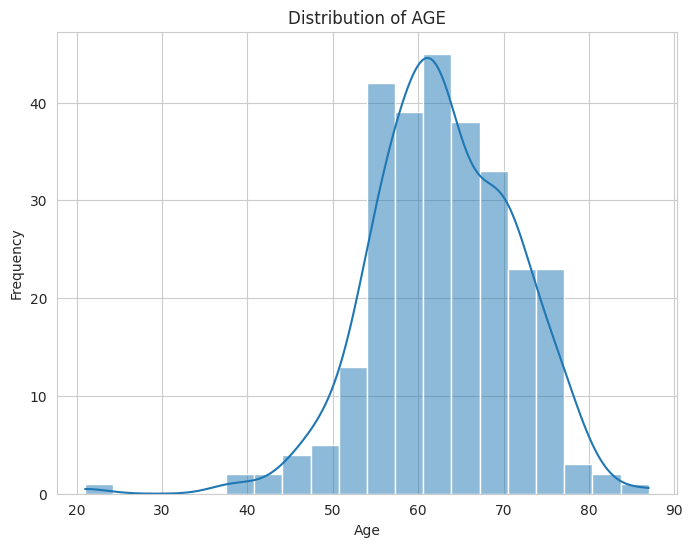

In [10]:
plt.figure(figsize=(8, 6))
sns.histplot(df['AGE'], bins=20, kde=True)
plt.title('Distribution of AGE')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [11]:
def remove_outliers(df, columns=None, drop_order=1):
    for _ in range(drop_order):
        for col in columns:
            q1 = df[col].quantile(0.25)
            q3 = df[col].quantile(0.75)
            iqr = q3 - q1

            df = df[df[col].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)]

    return df

In [12]:
df = remove_outliers(df, columns=["AGE"], drop_order=2)


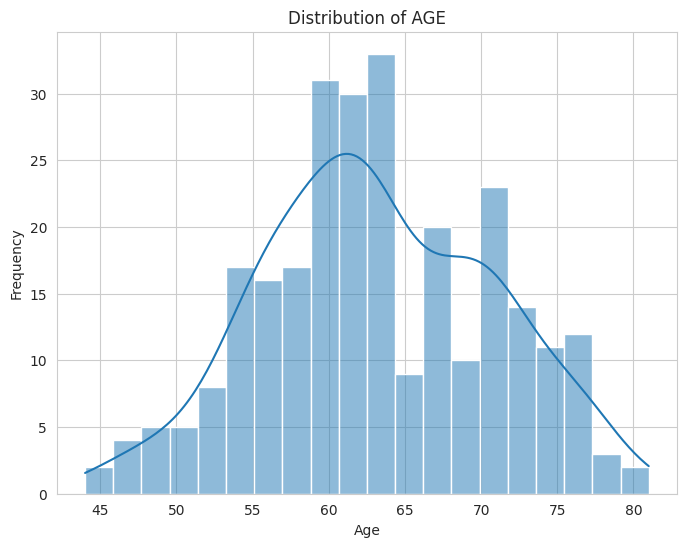

In [13]:
plt.figure(figsize=(8, 6))
sns.histplot(df['AGE'], bins=20, kde=True)
plt.title('Distribution of AGE')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [14]:
print (df['GENDER'].value_counts())

GENDER
1    141
0    131
Name: count, dtype: int64


In [15]:
print(df['GENDER'].unique())

[1 0]


Text(0, 0.5, '')

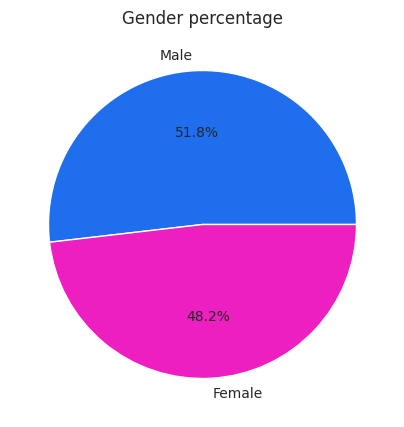

In [16]:
plt.figure(figsize=(5,5))
gender_counts = df['GENDER'].value_counts().rename({0: 'Female', 1: 'Male'})
gender_counts.plot.pie(autopct="%1.1f%%", colors=['#1f6eed', '#ed1fc0'])
plt.title('Gender percentage')
plt.ylabel('')

In [17]:
print(df['AGE'].describe().astype(int))

count    272
mean      63
std        7
min       44
25%       58
50%       63
75%       69
max       81
Name: AGE, dtype: int64


Data Overview

In [18]:
print("\nMissing values per column:\n", df.isnull().sum())


Missing values per column:
 GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64


## Univariate Analysis

Univariate analysis
looks at **one variable at a time**, independent of any other column. The goal here is simply to understand each feature on its own: how it's distributed, whether it's balanced or skewed, and what values it typically takes — before looking at how it relates to anything else.

In [19]:
print("\nTarget distribution:\n", df["LUNG_CANCER"].value_counts())


Target distribution:
 LUNG_CANCER
1    236
0     36
Name: count, dtype: int64


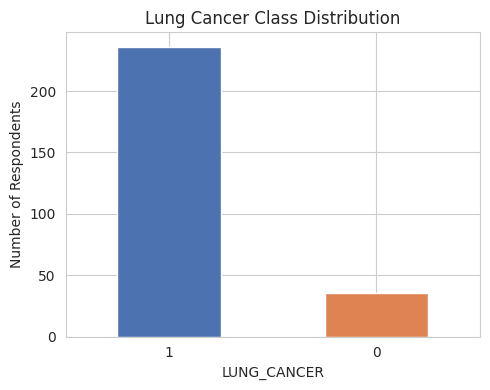

In [20]:
plt.figure(figsize=(5, 4))
df["LUNG_CANCER"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Lung Cancer Class Distribution")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

All symptom / lifestyle columns

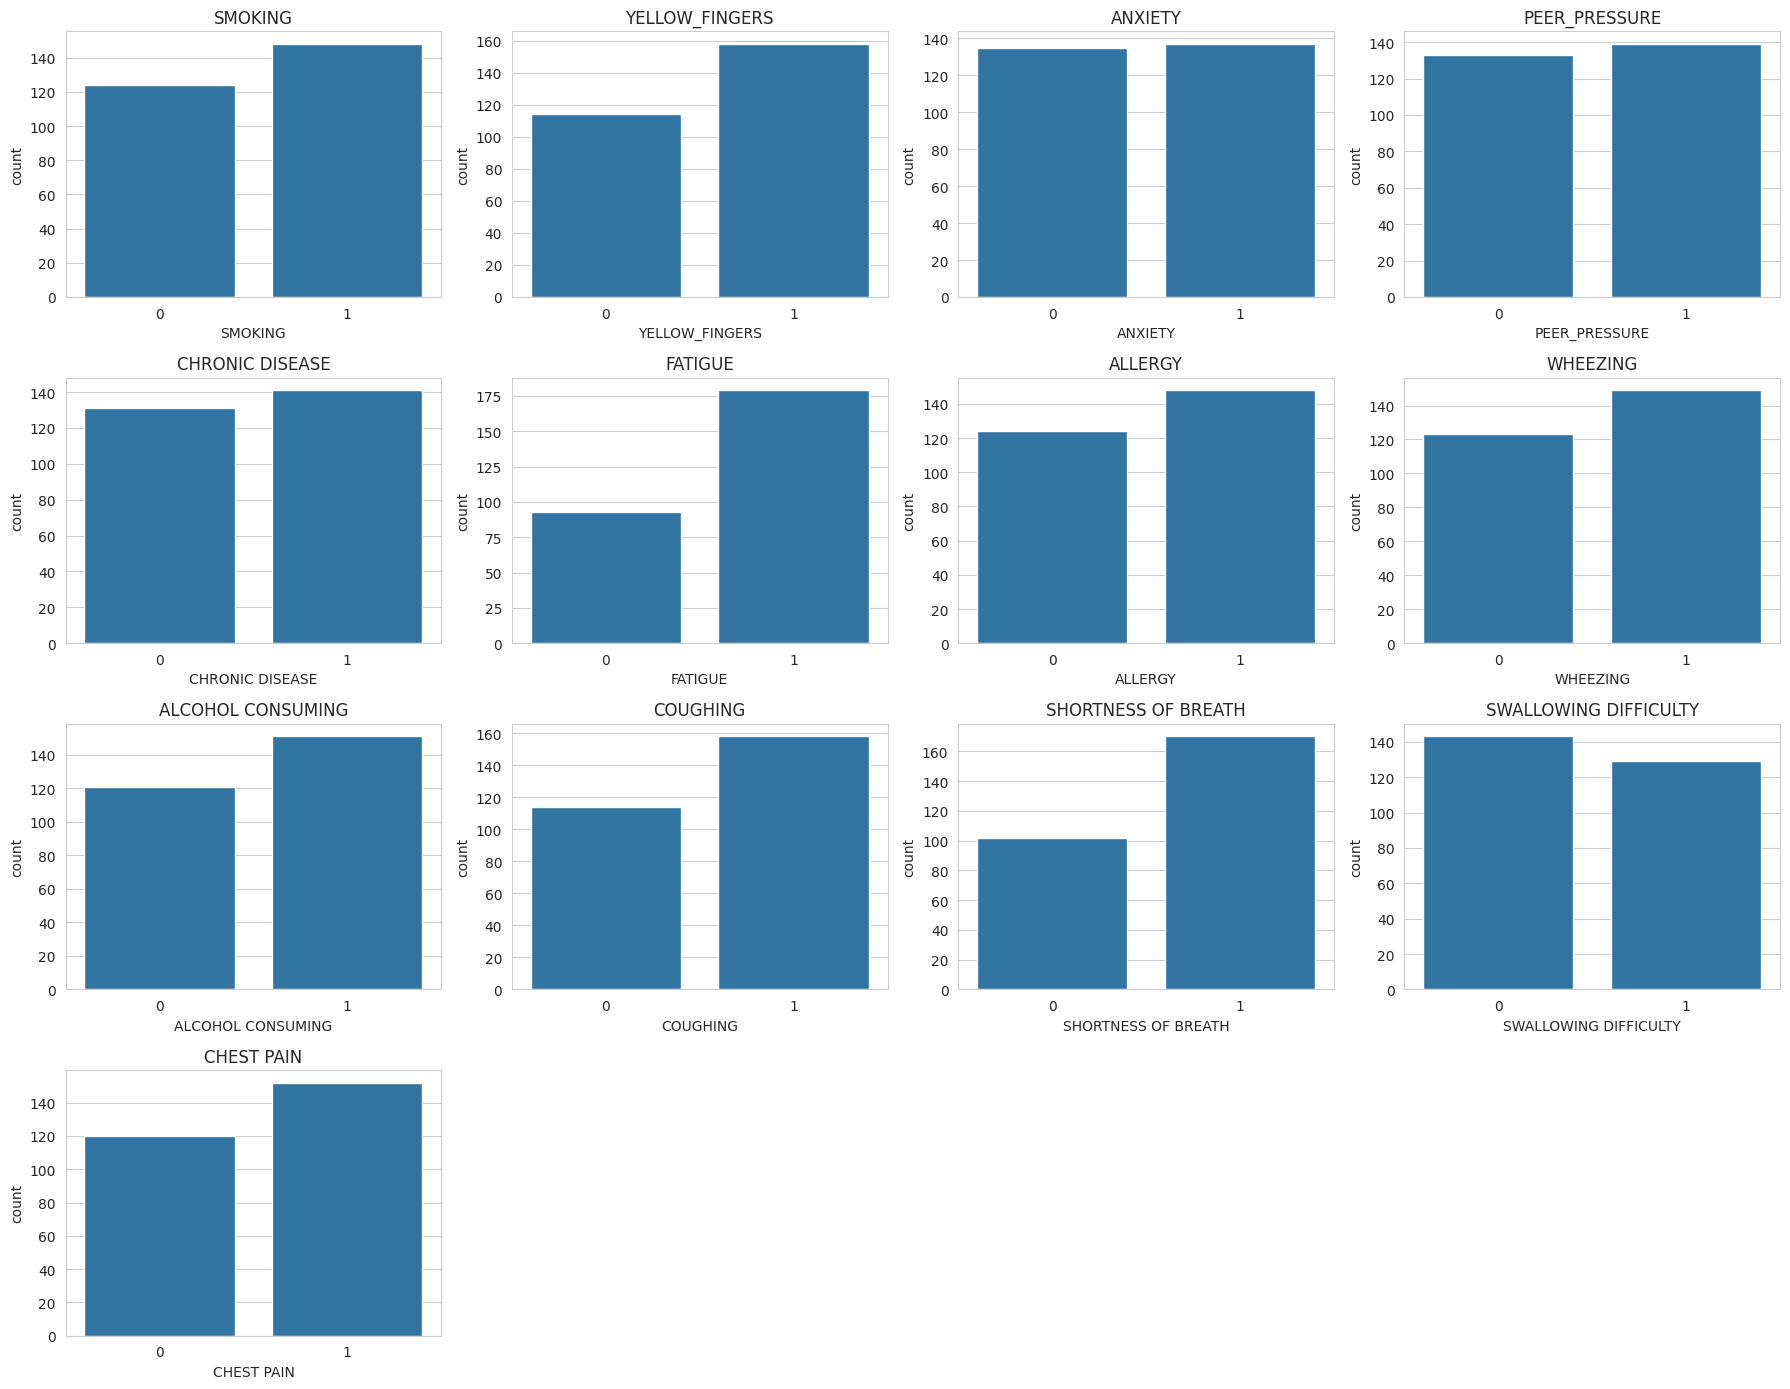

In [21]:
symptom_columns = ["SMOKING", "YELLOW_FINGERS", "ANXIETY", "PEER_PRESSURE",
                    "CHRONIC DISEASE", "FATIGUE", "ALLERGY", "WHEEZING",
                    "ALCOHOL CONSUMING", "COUGHING", "SHORTNESS OF BREATH",
                    "SWALLOWING DIFFICULTY", "CHEST PAIN"]

plt.figure(figsize=(18, 14))
for i, col in enumerate(symptom_columns, 1):
    plt.subplot(4, 4, i)
    sns.countplot(x=col, data=df)
    plt.title(col)
plt.tight_layout()
plt.show()

## Bivariate Analysis

Bivariate analysis looks at **two variables together** — almost always each feature against the target, `LUNG_CANCER`, here. The goal is to see whether a feature actually seems to relate to the diagnosis, not just what its own distribution looks like.

### Correlation of every feature with LUNG_CANCER

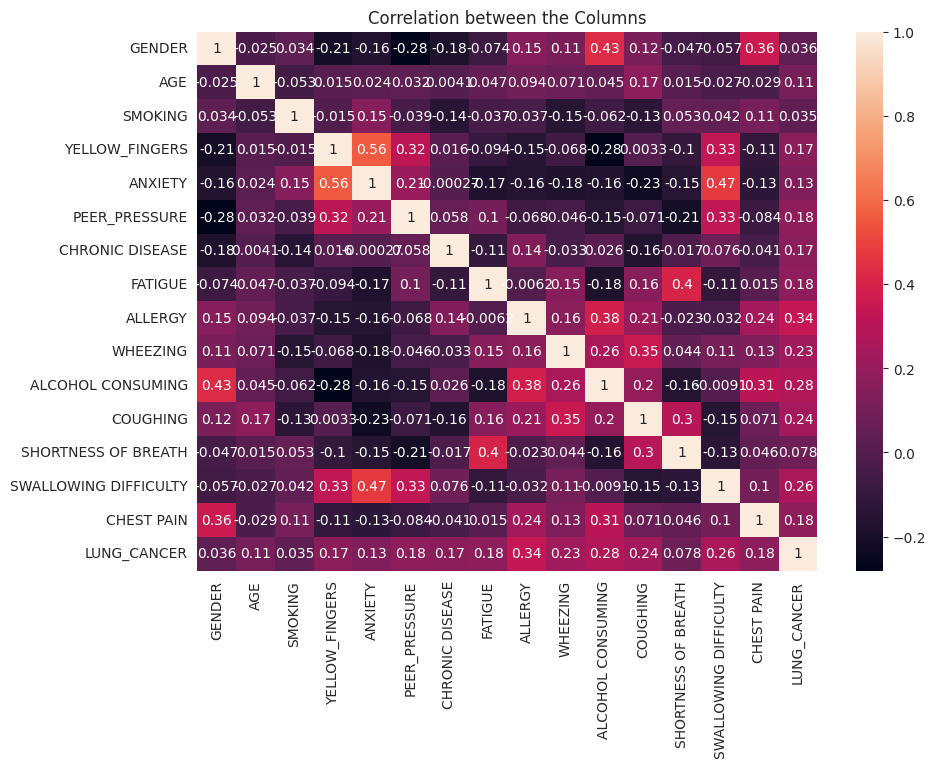

In [22]:
plt.figure(figsize=(10, 7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation between the Columns")
plt.show()

### Analysis: AGE vs LUNG_CANCER

In [23]:
print(df.groupby("LUNG_CANCER")["AGE"].describe())

             count       mean       std   min   25%   50%    75%   max
LUNG_CANCER                                                           
0             36.0  61.055556  5.966308  46.0  57.0  60.5  64.75  71.0
1            236.0  63.474576  7.810208  44.0  58.0  63.0  70.00  81.0


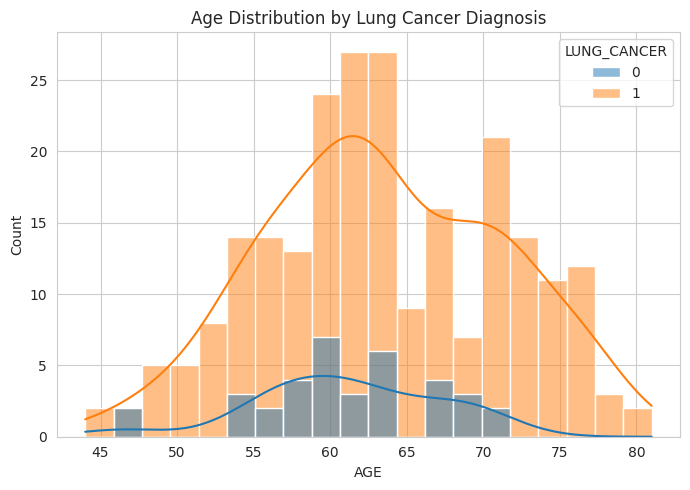

In [24]:
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x="AGE", hue="LUNG_CANCER", kde=True, bins=20)
plt.title("Age Distribution by Lung Cancer Diagnosis")
plt.tight_layout()
plt.show()

### GENDER vs LUNG_CANCER

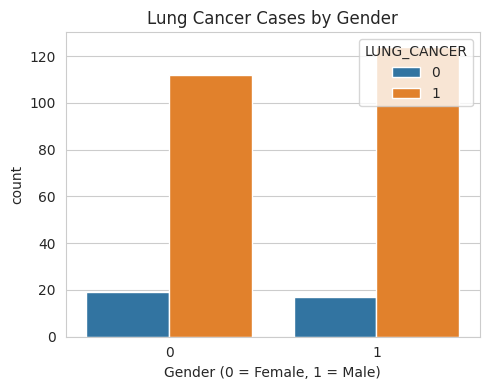

In [25]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="GENDER", hue="LUNG_CANCER")
plt.title("Lung Cancer Cases by Gender")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.tight_layout()
plt.show()

### SMOKING vs LUNG_CANCER

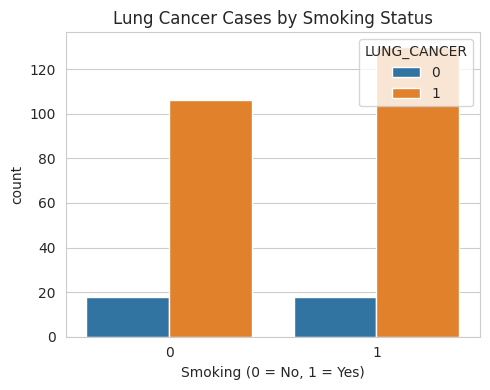

In [26]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="SMOKING", hue="LUNG_CANCER")
plt.title("Lung Cancer Cases by Smoking Status")
plt.xlabel("Smoking (0 = No, 1 = Yes)")
plt.tight_layout()
plt.show()

## Multivariate Analysis

Multivariate analysis looks at **three or more variables at once**, to see whether combinations of features reveal patterns that looking at one feature at a time would miss (for example, whether smoking's effect on lung cancer differs by gender).

### Analysis: GENDER & SMOKING combined vs LUNG_CANCER

In [27]:
pd.crosstab([df.GENDER, df.SMOKING], df.LUNG_CANCER)

LUNG_CANCER      0   1
GENDER SMOKING        
0      0        10  52
       1         9  60
1      0         8  54
       1         9  70

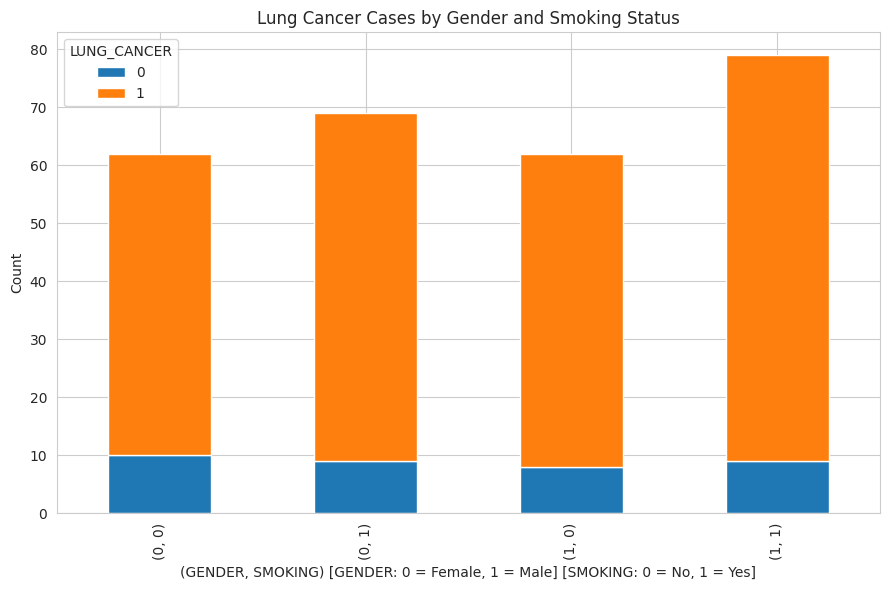

In [28]:
combo = df.groupby(["GENDER", "SMOKING", "LUNG_CANCER"]).size().unstack()
combo.plot(kind="bar", stacked=True, figsize=(9, 6))
plt.title("Lung Cancer Cases by Gender and Smoking Status")
plt.xlabel("(GENDER, SMOKING) [GENDER: 0 = Female, 1 = Male] [SMOKING: 0 = No, 1 = Yes]")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [29]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, RocCurveDisplay)

X = df.drop(columns=["LUNG_CANCER"])
y = df["LUNG_CANCER"]  # target variable


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # keep class ratios consistent across folds


In [30]:

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
}


grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_tree = grid_search.best_estimator_


y_pred = best_tree.predict(X_test)
y_proba = best_tree.predict_proba(X_test)[:, 1]


print("Best parameters:", grid_search.best_params_)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred):.3f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_proba):.3f}")
print("\nClassification report:\n", classification_report(y_test, y_pred))


Best parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy : 0.897
Precision: 0.948
Recall   : 0.932
F1-score : 0.940
ROC AUC  : 0.792

Classification report:
               precision    recall  f1-score   support

           0       0.60      0.67      0.63         9
           1       0.95      0.93      0.94        59

    accuracy                           0.90        68
   macro avg       0.77      0.80      0.79        68
weighted avg       0.90      0.90      0.90        68



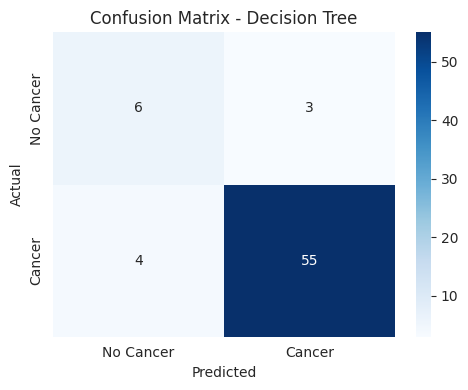

In [31]:
# visualize classification performance and error distribution
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Cancer", "Cancer"], yticklabels=["No Cancer", "Cancer"])
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()


/tmp/ipykernel_3309/546569875.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


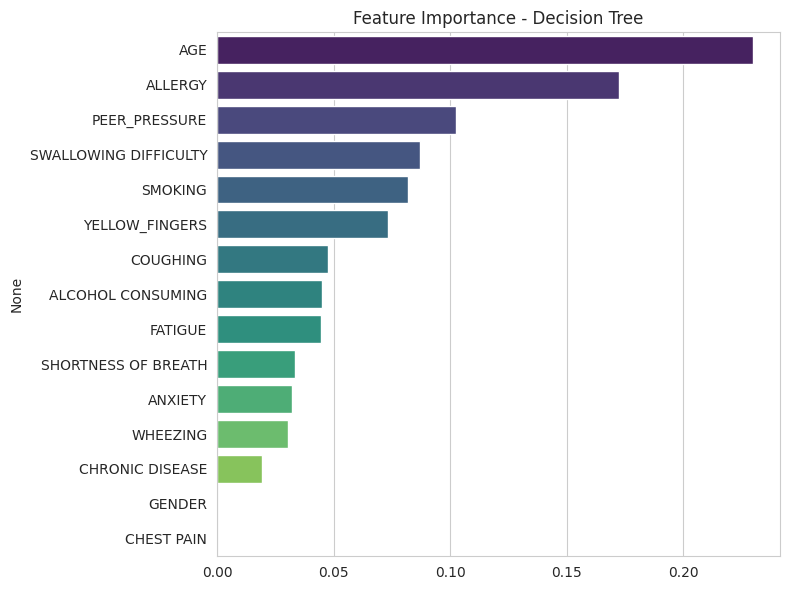

In [32]:
# inspect the decision tree's feature importance ranking
importances = pd.Series(best_tree.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Feature Importance - Decision Tree")
plt.tight_layout(); plt.show()


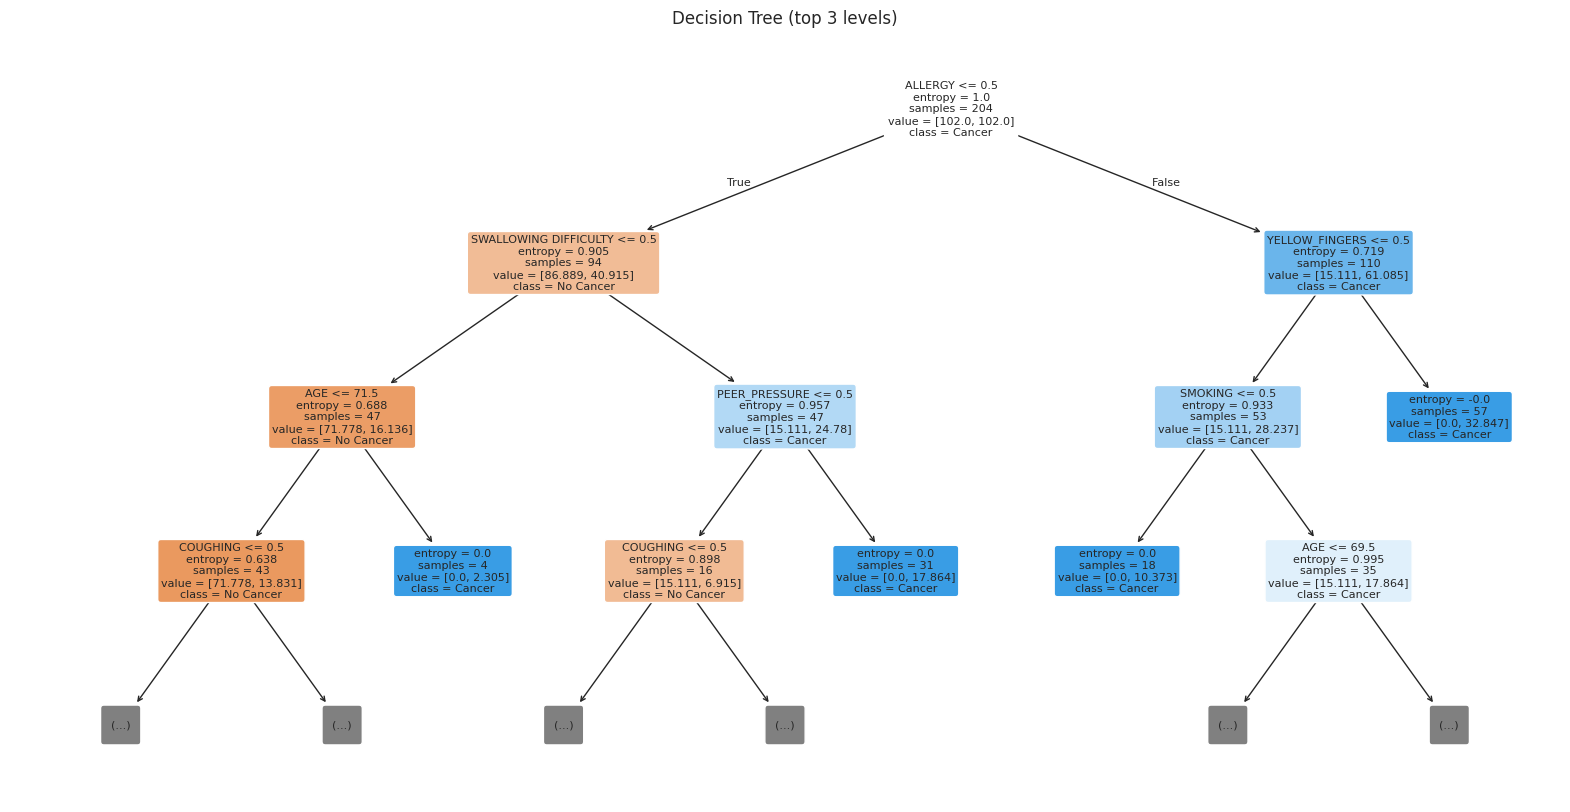

In [33]:
plt.figure(figsize=(20, 10))
plot_tree(best_tree,
          feature_names=X.columns,
          class_names=["No Cancer", "Cancer"],
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=3
          )
plt.title("Decision Tree (top 3 levels)")
plt.show()

In [34]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
}

# use F1 score to account for class imbalance during hyperparameter tuning
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_grid=param_grid_rf,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)
grid_search_rf.fit(X_train, y_train)
best_forest = grid_search_rf.best_estimator_  # best tuned random forest model


y_pred_rf = best_forest.predict(X_test)
y_proba_rf = best_forest.predict_proba(X_test)[:, 1]

# report best hyperparameters and evaluation metrics for the random forest
print("Best parameters:", grid_search_rf.best_params_)
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred_rf):.3f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_proba_rf):.3f}")
print("\nClassification report:\n", classification_report(y_test, y_pred_rf))


Best parameters: {'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Accuracy : 0.926
Precision: 0.935
Recall   : 0.983
F1-score : 0.959
ROC AUC  : 0.977

Classification report:
               precision    recall  f1-score   support

           0       0.83      0.56      0.67         9
           1       0.94      0.98      0.96        59

    accuracy                           0.93        68
   macro avg       0.88      0.77      0.81        68
weighted avg       0.92      0.93      0.92        68



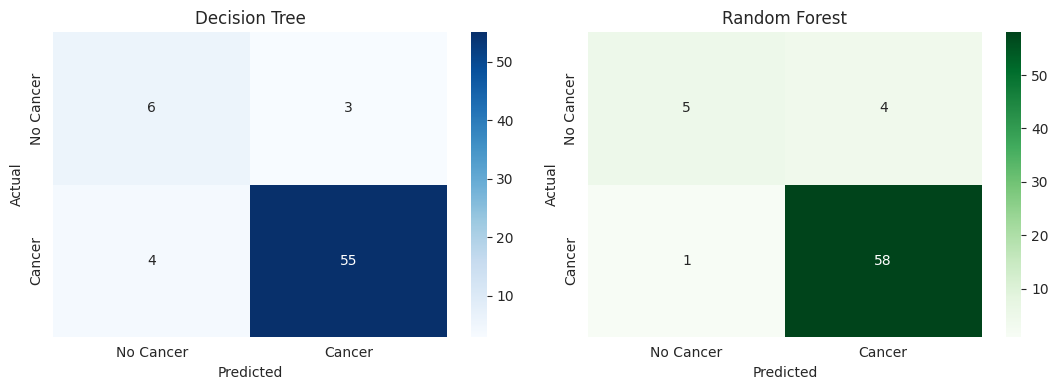

In [35]:

cm_rf = confusion_matrix(y_test, y_pred_rf)
# compare decision tree and random forest confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Cancer", "Cancer"], yticklabels=["No Cancer", "Cancer"], ax=axes[0])
axes[0].set_title("Decision Tree")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Cancer", "Cancer"], yticklabels=["No Cancer", "Cancer"], ax=axes[1])
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

/tmp/ipykernel_3309/836052652.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_rf.values, y=importances_rf.index, palette="viridis")


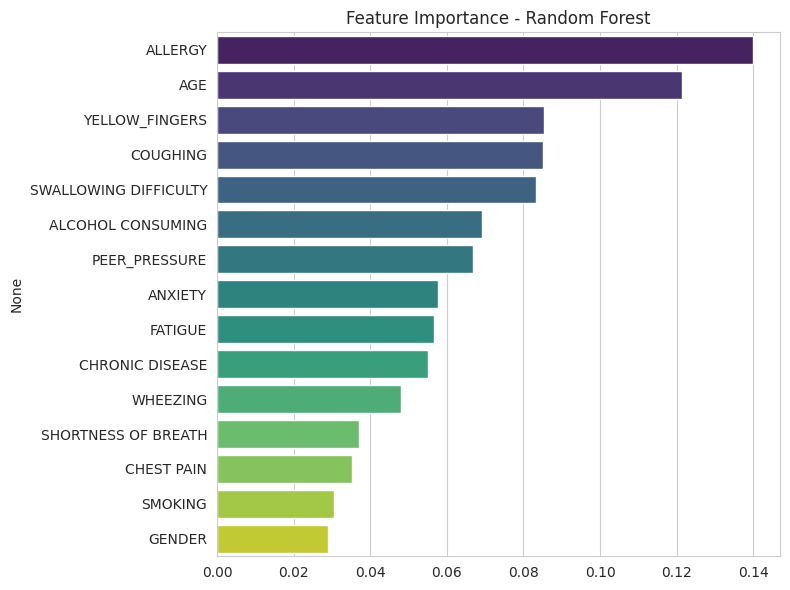

In [36]:

# display feature importance from the random forest model
importances_rf = pd.Series(best_forest.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=importances_rf.values, y=importances_rf.index, palette="viridis")
plt.title("Feature Importance - Random Forest")
plt.tight_layout(); plt.show()

In [37]:
from sklearn.ensemble import AdaBoostClassifier
param_grid_ada={'n_estimators':[50,100,250,500],'learning_rate':[0.01,0.05,0.1,0.2,0.5,1]}
grid_search_ada=GridSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    param_grid=param_grid_ada,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)

from sklearn.utils.class_weight import compute_sample_weight
sample_weights_ada = compute_sample_weight(class_weight='balanced', y=y_train)
grid_search_ada.fit(X_train,y_train,sample_weight=sample_weights_ada)
best_ada=grid_search_ada.best_estimator_

y_pred_ada=best_ada.predict(X_test)
y_proba_ada=best_ada.predict_proba(X_test)[:, 1]

print("Best parameters:", grid_search_ada.best_params_)
print(f"Accuracy : {accuracy_score(y_test, y_pred_ada):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_ada):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred_ada):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred_ada):.3f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_proba_ada):.3f}")
print("\nClassification report:\n", classification_report(y_test, y_pred_ada))

Best parameters: {'learning_rate': 1, 'n_estimators': 100}
Accuracy : 0.926
Precision: 0.982
Recall   : 0.932
F1-score : 0.957
ROC AUC  : 0.964

Classification report:
               precision    recall  f1-score   support

           0       0.67      0.89      0.76         9
           1       0.98      0.93      0.96        59

    accuracy                           0.93        68
   macro avg       0.82      0.91      0.86        68
weighted avg       0.94      0.93      0.93        68



/tmp/ipykernel_3309/2181352645.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_ada.values, y=importances_ada.index, palette="viridis")


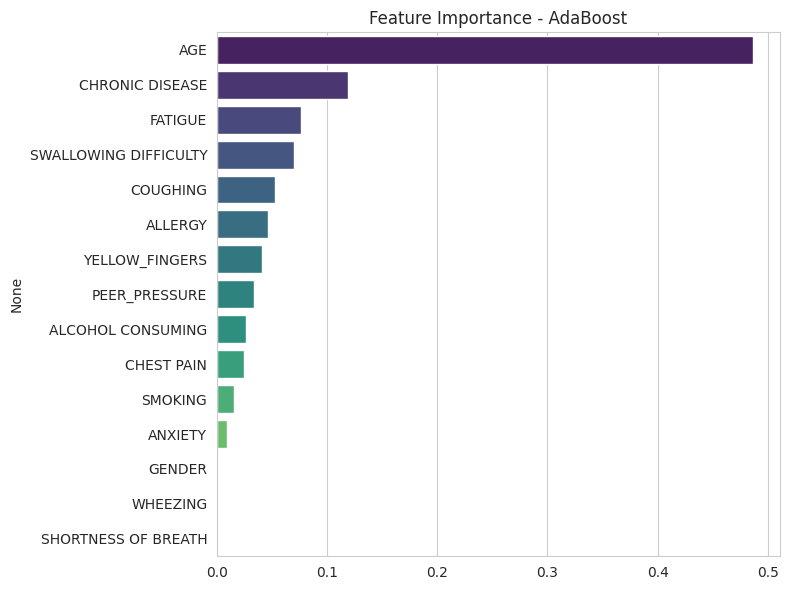

In [38]:
importances_ada = pd.Series(best_ada.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=importances_ada.values, y=importances_ada.index, palette="viridis")
plt.title("Feature Importance - AdaBoost")
plt.tight_layout(); plt.show()

In [39]:
from sklearn.ensemble import GradientBoostingClassifier
param_grid_gb={
    'n_estimators':[50,100,250,500],
    'learning_rate':[0.01,0.05,0.1,0.2,0.5,1],
    'max_depth':[3,4,5,6,7,8,9,10]
}
grid_search_gb=GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid_gb,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)

sample_weights_gb = compute_sample_weight(class_weight='balanced', y=y_train)
grid_search_gb.fit(X_train,y_train,sample_weight=sample_weights_gb)
best_gb=grid_search_gb.best_estimator_

y_pred_gb=best_gb.predict(X_test)
y_proba_gb=best_gb.predict_proba(X_test)[:, 1]

print("Best parameters:", grid_search_gb.best_params_)
print(f"Accuracy : {accuracy_score(y_test, y_pred_gb):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_gb):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred_gb):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred_gb):.3f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_proba_gb):.3f}")
print("\nClassification report:\n", classification_report(y_test, y_pred_gb))

Best parameters: {'learning_rate': 1, 'max_depth': 5, 'n_estimators': 50}
Accuracy : 0.912
Precision: 0.934
Recall   : 0.966
F1-score : 0.950
ROC AUC  : 0.872

Classification report:
               precision    recall  f1-score   support

           0       0.71      0.56      0.62         9
           1       0.93      0.97      0.95        59

    accuracy                           0.91        68
   macro avg       0.82      0.76      0.79        68
weighted avg       0.91      0.91      0.91        68



/tmp/ipykernel_3309/2524984184.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_gb.values, y=importances_gb.index, palette="viridis")


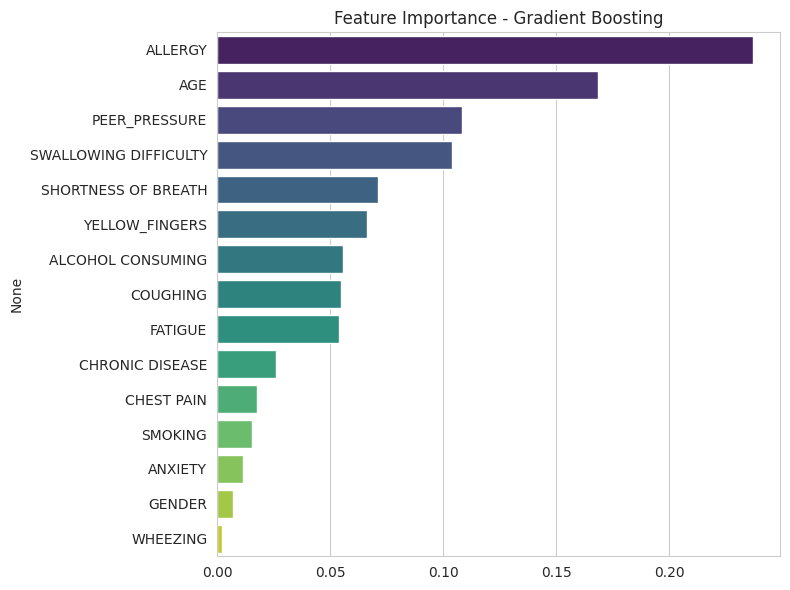

In [40]:
importances_gb = pd.Series(best_gb.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=importances_gb.values, y=importances_gb.index, palette="viridis")
plt.title("Feature Importance - Gradient Boosting")
plt.tight_layout(); plt.show()

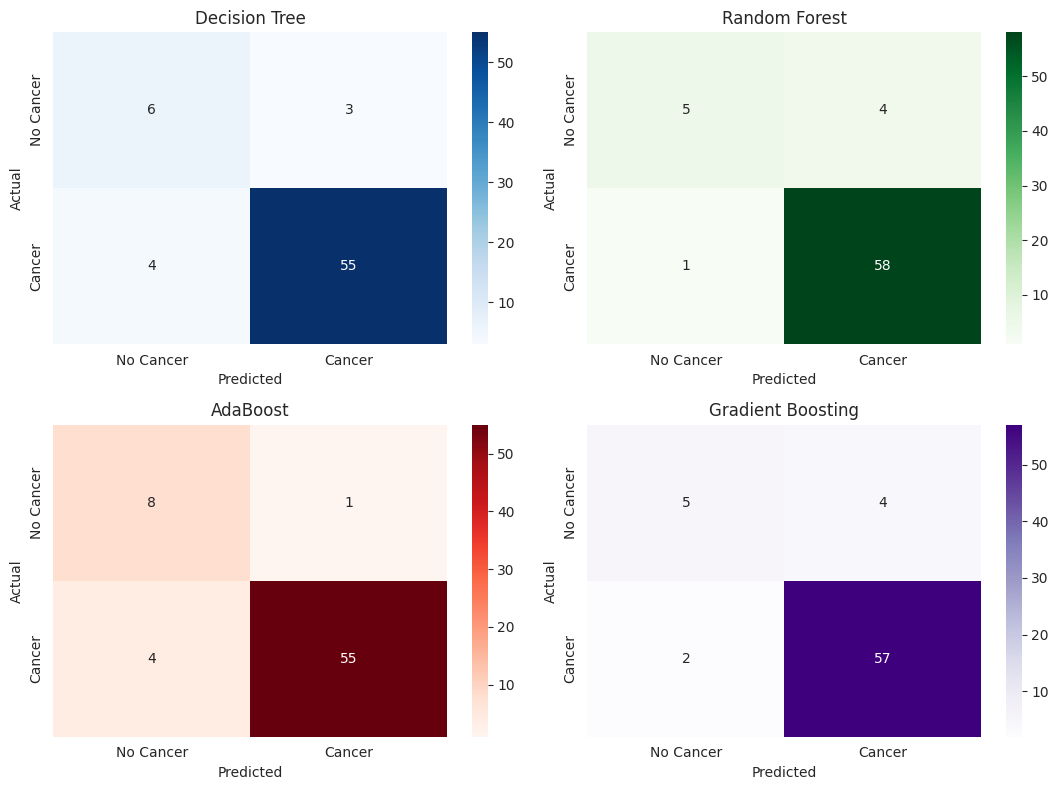

In [41]:
cm_ada = confusion_matrix(y_test, y_pred_ada)
cm_gb = confusion_matrix(y_test, y_pred_gb)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Cancer", "Cancer"], yticklabels=["No Cancer", "Cancer"], ax=axes[0,0])
axes[0,0].set_title("Decision Tree")
axes[0,0].set_xlabel("Predicted"); axes[0,0].set_ylabel("Actual")

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Cancer", "Cancer"], yticklabels=["No Cancer", "Cancer"], ax=axes[0,1])
axes[0,1].set_title("Random Forest")
axes[0,1].set_xlabel("Predicted"); axes[0,1].set_ylabel("Actual")

sns.heatmap(cm_ada, annot=True, fmt="d", cmap="Reds",
            xticklabels=["No Cancer", "Cancer"], yticklabels=["No Cancer", "Cancer"], ax=axes[1,0])
axes[1,0].set_title("AdaBoost")
axes[1,0].set_xlabel("Predicted"); axes[1,0].set_ylabel("Actual")

sns.heatmap(cm_gb, annot=True, fmt="d", cmap="Purples",
            xticklabels=["No Cancer", "Cancer"], yticklabels=["No Cancer", "Cancer"], ax=axes[1,1])
axes[1,1].set_title("Gradient Boosting")
axes[1,1].set_xlabel("Predicted"); axes[1,1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [42]:
print("\nClassification report Decision Tree:\n", classification_report(y_test, y_pred))
print("\nClassification report Random Forest:\n", classification_report(y_test, y_pred_rf))
print("\nClassification report AdaBoost:\n", classification_report(y_test, y_pred_ada))
print("\nClassification report Gradient Boosting:\n", classification_report(y_test, y_pred_gb))


Classification report Decision Tree:
               precision    recall  f1-score   support

           0       0.60      0.67      0.63         9
           1       0.95      0.93      0.94        59

    accuracy                           0.90        68
   macro avg       0.77      0.80      0.79        68
weighted avg       0.90      0.90      0.90        68


Classification report Random Forest:
               precision    recall  f1-score   support

           0       0.83      0.56      0.67         9
           1       0.94      0.98      0.96        59

    accuracy                           0.93        68
   macro avg       0.88      0.77      0.81        68
weighted avg       0.92      0.93      0.92        68


Classification report AdaBoost:
               precision    recall  f1-score   support

           0       0.67      0.89      0.76         9
           1       0.98      0.93      0.96        59

    accuracy                           0.93        68
   macro avg    

In [43]:
models = {
    'Decision Tree': best_tree,
    'Random Forest': best_forest,
    'AdaBoost': best_ada,
    'Gradient Boosting': best_gb
}

cv_scores = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    cv_scores[name] = scores.mean()

best_name = max(cv_scores, key=cv_scores.get)

print("Cross-validated F1 scores:")
for name, score in cv_scores.items():
    print(f"  {name}: {score:.4f}")
print(f"\nBest model based on CV F1: {best_name}")

Cross-validated F1 scores:
  Decision Tree: 0.9030
  Random Forest: 0.9456
  AdaBoost: 0.9385
  Gradient Boosting: 0.9267

Best model based on CV F1: Random Forest


In [44]:
y_pred_final=models[best_name].predict(X_test)
print(f"From {len(X_test)} patients who tested here,there are {y_pred_final.sum()} who have lung cancer")

From 68 patients who tested here,there are 62 who have lung cancer


In [45]:
import joblib
import gradio as gr

filenameC = 'Lung_Cancer.joblib'
best_model = models[best_name]
joblib.dump(best_model, filenameC)
loaded_model = joblib.load(filenameC)

# define prediction function for the Gradio interface

def predict_lung_cancer(
    gender, age, smoking, yellow_fingers, anxiety, peer_pressure,
    chronic_disease, fatigue, allergy, wheezing, alcohol_consuming,
    coughing, shortness_of_breath, swallowing_difficulty, chest_pain
):
    new_data = [[
        gender, age, smoking, yellow_fingers, anxiety, peer_pressure,
        chronic_disease, fatigue, allergy, wheezing, alcohol_consuming,
        coughing, shortness_of_breath, swallowing_difficulty, chest_pain
    ]]
    pred = loaded_model.predict(new_data)[0]
    return "Cancer" if pred == 1 else "No Cancer"

iface = gr.Interface(
    fn=predict_lung_cancer,
    inputs=[
        gr.Radio([0, 1], label="Gender (0=Female, 1=Male)"),
        gr.Number(value=30, label="Age", precision=0),
        gr.Radio([0, 1], label="Smoking"),
        gr.Radio([0, 1], label="Yellow Fingers"),
        gr.Radio([0, 1], label="Anxiety"),
        gr.Radio([0, 1], label="Peer Pressure"),
        gr.Radio([0, 1], label="Chronic Disease"),
        gr.Radio([0, 1], label="Fatigue"),
        gr.Radio([0, 1], label="Allergy"),
        gr.Radio([0, 1], label="Wheezing"),
        gr.Radio([0, 1], label="Alcohol Consuming"),
        gr.Radio([0, 1], label="Coughing"),
        gr.Radio([0, 1], label="Shortness of Breath"),
        gr.Radio([0, 1], label="Swallowing Difficulty"),
        gr.Radio([0, 1], label="Chest Pain")
    ],
    outputs="text",
    title="Lung Cancer Prediction",
    description="Enter patient symptoms and get a lung cancer prediction."
)

iface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2227d1bfe2b06f7290.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
